# Odd Viscosity

In [5]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean
import os
import sys, time,random
from pathlib import Path
from PIL import Image
from joblib import Parallel, delayed
import h5py
from skimage.measure import label, regionprops


sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

def shear_amplitude_order(uv_list, boundary=50):
    '''sort by shear amplitude
    uv_list sotred by shear (v_y) amplitude on the edges'''

    shear_amplitude = [(uv[:,-boundary:,1].mean() - uv[:,:boundary,1].mean()) for uv in uv_list]
    return np.argsort(shear_amplitude)


def interpolate_arrays(arrays):
    '''make all arrays the same length'''
    
    target_length = max(len(arr) for arr in arrays)
    interpolated_arrays = []
    
    for arr in arrays:
        # Create an array of indices for the original array
        original_indices = np.linspace(0, 1, len(arr))
        # Create an array of indices for the target length
        target_indices = np.linspace(0, 1, target_length)
        
        # Interpolate the values
        interpolated_array = np.interp(target_indices, original_indices, arr)
        interpolated_arrays.append(interpolated_array)
    
    return interpolated_arrays

def uv_save_from_multitiff(tiff_path, save_dir):
    '''save uv from multi tiff'''

    tiff = Image.open(tiff_path)
    tiff_frame_list = multiTiff_to_list(tiff)

    exp_num = os.path.basename(tiff_path).split(".")[-2]
    save_path  = save_dir + exp_num + "/Flow"
    os.makedirs(save_path, exist_ok=True)

    for (i,img1),img2 in zip(enumerate(tiff_frame_list[:-1]), tiff_frame_list[1:]):
        flow = cv2.calcOpticalFlowFarneback(img1,img2, None, 0.5, 3, 
            winsize=15, iterations=3, poly_n=5, poly_sigma=1.2, flags=0) 
        
        with h5py.File(save_path +"/flow_"+ str(i), 'w') as f:
            f.create_dataset('flow', data=flow.astype(np.float16))
    
    return 

def uv_save(tiff_frame_list, save_path):
    os.makedirs(save_path, exist_ok=True)

    for (i,img1),img2 in zip(enumerate(tiff_frame_list[:-1]), tiff_frame_list[1:]):
        flow = cv2.calcOpticalFlowFarneback(img1,img2, None, 0.5, 3, 
            winsize=15, iterations=3, poly_n=5, poly_sigma=1.2, flags=0) 

        with h5py.File(save_path +"/flow_"+ str(i), 'w') as f:
            f.create_dataset('flow', data=flow.astype(np.float16))

In [27]:
# find foldes with Mask images
image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\Odd_test\*\*\Mask2")
image_list = natsorted(image_list, key=lambda y: y.lower())


## Create list of stripes in range <>

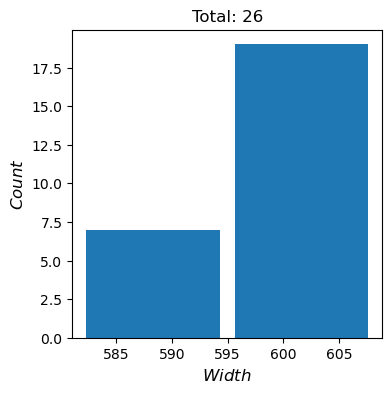

In [29]:
%matplotlib inline
# Example usage
# fig, ax = plt.subplots(1,1,  figsize=(4,4))
stripe_width = 600
dw = stripe_width//30
tiff_list = analyze_image_widths(r"C:\Users\victo\Downloads\HT1080", stripe_width, dw=dw, make_plot=True)#, ax=ax)

In [4]:
# calculate average flow for each stripe  
uv_list = Parallel(n_jobs=5)(delayed(uv_time_average)(tiff_path) for tiff_path in tiff_list[:])
# remove None
uv_list1 = [uv for uv,ti in zip(uv_list, tiff_list) if uv is not None]
tiff_list1 = [ti for uv,ti in zip(uv_list, tiff_list) if uv is not None]
print(len(tiff_list1), " from ", len(tiff_list))

16  from  26


C:\Users\victo\AppData\Local\Temp\ipykernel_41908\212570760.py:19: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  for c,uv in zip(colors, np.array(uv_list1)[idx[::-1][:num]]):


Text(0.5, 1.0, '$Sorted$')

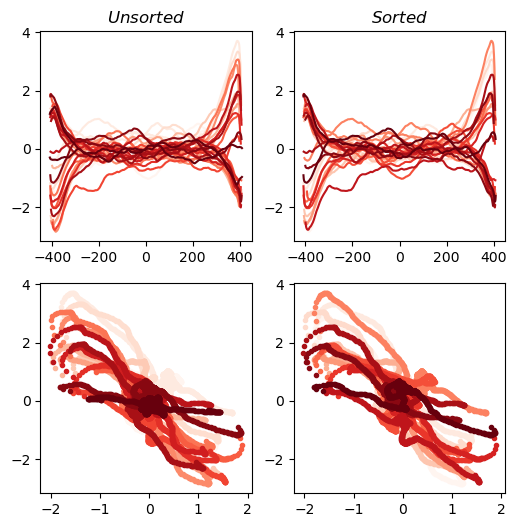

In [5]:

import matplotlib.cm as cm
colors = cm.Reds(np.linspace(0, 1, len(uv_list1)))

fig, axs = plt.subplots(2,2, figsize=(6,6))
axs = axs.flatten()

for c,uv in zip(colors,uv_list1):
    u_profile = uv[:,:,0].mean(axis=0)
    v_profile = uv[:,:,1].mean(axis=0)
    width = np.linspace(-len(u_profile) // 2, len(u_profile) // 2, len(u_profile))
    axs[0].plot(width, v_profile, color=c)
    axs[0].plot(width, u_profile, color=c)
    axs[2].plot(u_profile, v_profile, ".", color=c)
axs[0].set_title("$Unsorted$")

num = 15
colors = cm.Reds(np.linspace(0, 1, num))
idx = shear_amplitude_order(uv_list1)
for c,uv in zip(colors, np.array(uv_list1)[idx[::-1][:num]]):
    u_profile = uv[:,:,0].mean(axis=0)
    v_profile = uv[:,:,1].mean(axis=0)
    width = np.linspace(-len(u_profile) // 2, len(u_profile) // 2, len(u_profile))
    axs[1].plot(width, v_profile, color=c)
    axs[1].plot(width, u_profile, color=c)
    axs[3].plot(u_profile, v_profile, ".", color=c)
axs[1].set_title("$Sorted$")  



C:\Users\victo\AppData\Local\Temp\ipykernel_41908\955274978.py:2: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  u_list = [uv[:,:,0].mean(axis=0) for uv in np.array(uv_list1)[idx[::-1][:num]]]
C:\Users\victo\AppData\Local\Temp\ipykernel_41908\955274978.py:3: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  v_list = [uv[:,:,1].mean(axis=0) for uv in np.array(uv_list1)[idx[::-1][:num]]]


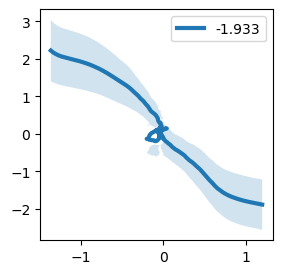

In [6]:
num = 10
u_list = [uv[:,:,0].mean(axis=0) for uv in np.array(uv_list1)[idx[::-1][:num]]]
v_list = [uv[:,:,1].mean(axis=0) for uv in np.array(uv_list1)[idx[::-1][:num]]]

u_mean = np.mean(interpolate_arrays(u_list), axis=0)[dw:-dw]
u_std = np.std(interpolate_arrays(u_list), axis=0)[dw:-dw]
v_mean = np.mean(interpolate_arrays(v_list), axis=0)[dw:-dw]
v_std = np.std(interpolate_arrays(v_list), axis=0)[dw:-dw]

fig, ax = plt.subplots(1,1, figsize=(3,3))
ax.plot(u_mean, v_mean, "-", linewidth=3, label="%.3f" %np.polyfit(u_mean, v_mean, 1)[0])
ax.fill_between(u_mean, v_mean - v_std, v_mean + v_std, alpha=0.2)
plt.legend()



In [117]:
np.polyfit(u_mean, v_mean, 1)

array([-1.64530544, -0.0616642 ])

In [ ]:
wws = [300, 400, 500, 600, 800, 1000]

for width in wws:
    tiff_list = analyze_image_widths(r"C:\Users\victo\Downloads\HT1080", width, dw=width//30, make_plot=False)#, ax=ax)
    uv_list = Parallel(n_jobs=5)(delayed(uv_time_average)(tiff_path) for tiff_path in tiff_list[:])
    # remove None
    uv_list1 = [uv for uv,ti in zip(uv_list, tiff_list) if uv is not None]
    tiff_list1 = [ti for uv,ti in zip(uv_list, tiff_list) if uv is not None]
    print(len(tiff_list1), " from ", len(tiff_list))

    idx = shear_amplitude_order(uv_list1) 

    save_dir = r"C:\Users\victo\Downloads\HT1080\Odd_test/w"+str(width)+ "/"
    os.makedirs(save_path, exist_ok=True)

    Parallel(n_jobs=15)(delayed(uv_save_from_multitiff)(tiff_path, save_dir) for tiff_path in np.array(tiff_list1)[idx[::-1]][:3])
            # if i>3:
            #     break

16  from  26


C:\Users\victo\AppData\Local\Temp\ipykernel_41912\2707329951.py:16: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  u_list = [uv[:,:,0].mean(axis=0) for uv in np.array(uv_list1)[idx[::-1][:num]]]
C:\Users\victo\AppData\Local\Temp\ipykernel_41912\2707329951.py:17: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  v_list = [uv[:,:,1].mean(axis=0) for uv in np.array(uv_list1)[idx[::-1][:num]]]


35  from  43
18  from  29


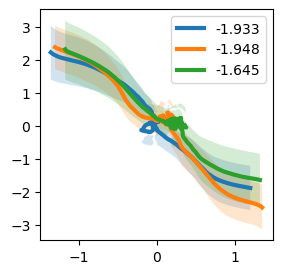

In [13]:
wws = [300, 400, 500, 600, 800, 1000]

fig, ax = plt.subplots(1,1, figsize=(3,3))

for width in wws[3:]:
    tiff_list = analyze_image_widths(r"C:\Users\victo\Downloads\HT1080", width, dw=width//30, make_plot=False)#, ax=ax)
    uv_list = Parallel(n_jobs=5)(delayed(uv_time_average)(tiff_path) for tiff_path in tiff_list[:])
    # remove None
    uv_list1 = [uv for uv,ti in zip(uv_list, tiff_list) if uv is not None]
    tiff_list1 = [ti for uv,ti in zip(uv_list, tiff_list) if uv is not None]
    print(len(tiff_list1), " from ", len(tiff_list))

    idx = shear_amplitude_order(uv_list1) 

    num = 10
    u_list = [uv[:,:,0].mean(axis=0) for uv in np.array(uv_list1)[idx[::-1][:num]]]
    v_list = [uv[:,:,1].mean(axis=0) for uv in np.array(uv_list1)[idx[::-1][:num]]]

    u_mean = np.mean(interpolate_arrays(u_list), axis=0)[dw:-dw]
    u_std = np.std(interpolate_arrays(u_list), axis=0)[dw:-dw]
    v_mean = np.mean(interpolate_arrays(v_list), axis=0)[dw:-dw]
    v_std = np.std(interpolate_arrays(v_list), axis=0)[dw:-dw]

    ax.plot(u_mean, v_mean, "-", linewidth=3, label="%.3f" %np.polyfit(u_mean, v_mean, 1)[0])
    ax.fill_between(u_mean, v_mean - v_std, v_mean + v_std, alpha=0.2)

plt.legend()


## Average Flows

In [7]:
from cellpose.io import imread
idx = shear_amplitude_order(uv_list1) 
t = tiff_list1[idx[::-1][1]]
frame_num,_ , im_width  = imread(t).shape

100%|██████████| 101/101 [00:00<00:00, 337.88it/s]


In [74]:
t = exp_list[7]
tiff = Image.open(t)
tiff_frame_list = multiTiff_to_list(tiff)

In [ ]:
def defects_in_all_frames(tiff_frame_list, sigma=30):

    plushalf_df = pd.DataFrame([])
    for i,im1 in enumerate(tiff_frame_list):    
        plushalf = analyze_defects(im1, sigma=sigma)[1]
        plushalf['frame'] = i
        plushalf_df = pd.concat([plushalf_df, plushalf], ignore_index=True)

        progressBar(i, len(tiff_frame_list))

df = defects_in_all_frames(tiff_frame_list)

In [75]:
# %matplotlib qt
box = 150
n = 14
img1 = tiff_frame_list[n]
y, x = np.mgrid[0:img1.shape[0], 0:img1.shape[1]]

sigma = 30
ori, plushalf, minushalf = analyze_defects(img1, sigma=sigma)
df_plus = pd.DataFrame()
df_plus[['xp', 'yp', 'angp1']] = plushalf[['x','y','ang1']].copy()  

# flow = cv2.calcOpticalFlowFarneback(tiff_frame_list[n],tiff_frame_list[n+1], None, 0.5, 3, 
#     winsize=sigma//2, iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
# flow[...,0] = gaussian_filter(flow[...,0], sigma=5)
# flow[...,1] = gaussian_filter(flow[...,1], sigma=5)

u_up, v_up, count = defect_flow_frame_average(tiff_frame_list[n],tiff_frame_list[n+1], 
                                              df_plus, defect_type="all",
                                              box=(box,box), filt=1, sigma=sigma//2,
                                              edge=150)      

106 106


In [25]:
u_up.shape

(106, 106)

In [76]:
count, plushalf.shape

(7, (28, 8))

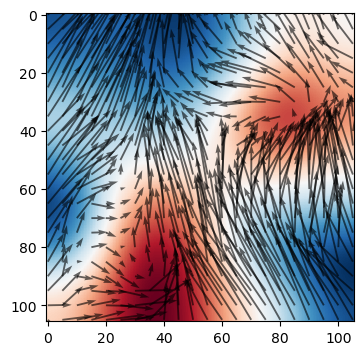

In [77]:
%matplotlib inline
fig, ax1 = plt.subplots(1,1, figsize=(4,4))
field = np.stack((u_up, v_up), axis=-1)
y, x = np.mgrid[0:u_up.shape[0], 0:u_up.shape[1]] 
step = 5
vorticity = gaussian_filter(curl_npgrad(field), sigma=15)
c1 = ax1.imshow(vorticity, cmap='RdBu')#, vmin=-vort_mag, vmax=vort_mag)
ax1.quiver(x[::step, ::step], y[::step, ::step], 
          u_up[::step, ::step], -v_up[::step, ::step],  color='k',
          width=.006, scale=20, alpha=.6)

In [6]:
'''Find file'''
# Foldes with Mask images
image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\Odd_test\*\*\Mask2")

# All files in the folder
directory = r"C:\Users\victo\Downloads\HT1080"
all_files = glob.glob(f"{directory}\\*CROPPED*\\*.tif")

exp_list = []
bin_list = []

for exp in image_list:
    bin_width = int(Path(exp).parent.parent.name[1:])
    exp_name = Path(exp).parent.name 
    # Find the file
    res = [t for t in all_files if exp_name+'.tif' in t]
    # If more than one file check the width
    if len(res)>1:
        for r in res:
            if np.abs(bin_width - Image.open(r).size[0])<bin_width//30:
                exp_path = r
    else:
        exp_path = res[0]

    exp_list.append(exp_path)
    bin_list.append(bin_width)

exp_list, bin_list

(['C:\\Users\\victo\\Downloads\\HT1080\\01082018_TIFF_CROPPED\\s18.tif',
  'C:\\Users\\victo\\Downloads\\HT1080\\01082018_TIFF_CROPPED\\s20.tif',
  'C:\\Users\\victo\\Downloads\\HT1080\\01082018_TIFF_CROPPED\\s22.tif',
  'C:\\Users\\victo\\Downloads\\HT1080\\01082018_TIFF_CROPPED\\s22.tif',
  'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s65_2.tif',
  'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s65_2.tif',
  'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s65_2.tif',
  'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s88_3.tif',
  'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s90_2.tif',
  'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s90_2.tif',
  'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s90_2.tif',
  'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s223_1.tif',
  'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s215_1.tif',
  'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s217_2.tif',
  'C:

In [33]:
exp_list[2], bin_list[2]

('C:\\Users\\victo\\Downloads\\HT1080\\01082018_TIFF_CROPPED\\s22.tif', 1000)

In [78]:
tiff = Image.open(exp_list[7])
tiff_frame_list = multiTiff_to_list(tiff)


box = 150
ori_sigma = 21
flow_sigma = 15

frames_len = 10
u_v_count = Parallel(n_jobs=-1)(delayed(defect_flow_frame_average)(
    img1, img2, 
    analyze_defects(img1, sigma=ori_sigma)[1][['x','y','ang1']].rename(columns={"x":"xp", "y":"yp", "ang1":"angp1"}),
    defect_type="all", 
    box=(int(box),int(box)),
    sigma=flow_sigma,
    filt=5,
    # edge=0,
    edge=150,
    ) for img1,img2 in zip(tiff_frame_list[:frames_len], tiff_frame_list[1:frames_len+1]))


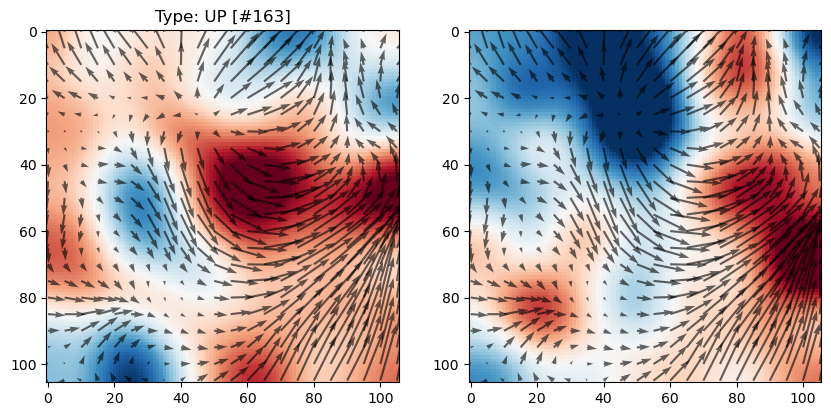

In [79]:
u, v, count = [], [], []
for q in u_v_count:
    if q:
        u.append(q[0])
        v.append(q[1])
        count.append(q[2])
u = np.array(u)
v = np.array(v)
count = np.array(count)  

n, m = 0,-1 #800,900 #600,800 #450,550 #150,250 #50,150
u_up = np.average(u[count!= 0][n:m,:,:], axis=0, weights=count[count!= 0][n:m])
v_up = np.average(v[count!= 0][n:m,:,:], axis=0, weights=count[count!= 0][n:m])

filt = 7
step = 5
vscale = 5
vort_mag, div_mag = .03, .03

fig, axs = plt.subplots(1,2, figsize=(10,5))
# for ax in axs.ravel(): ax.axis('off')
ax1, ax2 = axs.ravel()

field = np.stack((u_up, v_up), axis=-1)
y, x = np.mgrid[0:u_up.shape[0], 0:u_up.shape[1]] 
vorticity = gaussian_filter(curl_npgrad(field), sigma=filt)
c1 = ax1.imshow(vorticity, cmap='RdBu', vmin=-vort_mag, vmax=vort_mag)
ax1.quiver(x[::step, ::step], y[::step, ::step], 
          u_up[::step, ::step], -v_up[::step, ::step],  color='k',
          width=.006, scale=vscale, alpha=.6)
ax1.set_title("Type: %1s [#%1d]" % ("UP", np.sum(count)))

divergence = gaussian_filter(divergence_npgrad(field), sigma=filt)
c2 = ax2.imshow(divergence, cmap='RdBu', vmin=-div_mag, vmax=div_mag)
ax2.quiver(x[::step, ::step], y[::step, ::step], 
          u_up[::step, ::step], -v_up[::step, ::step],  color='k',
          width=.006, scale=vscale, alpha=.6)

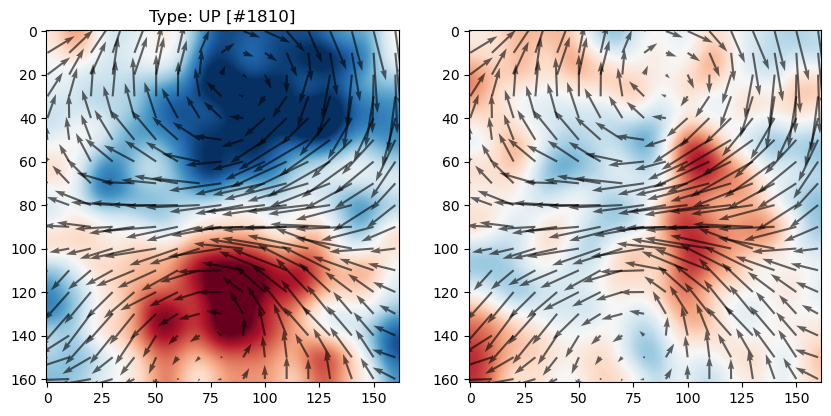

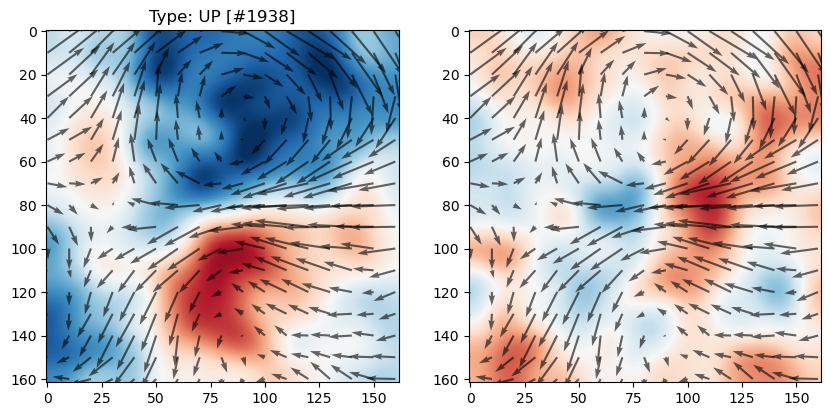

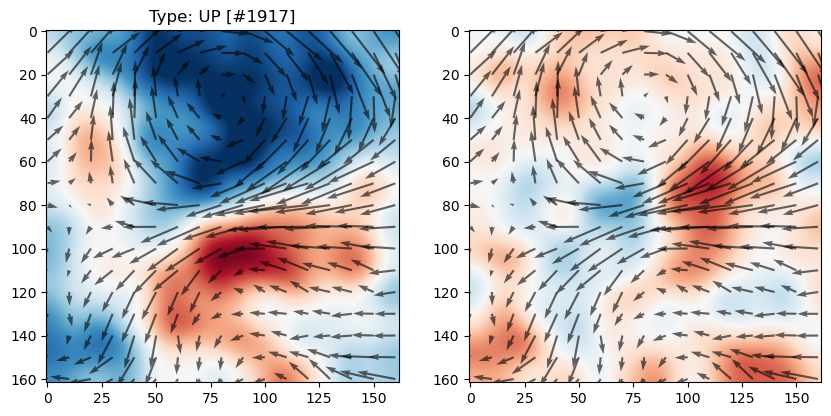

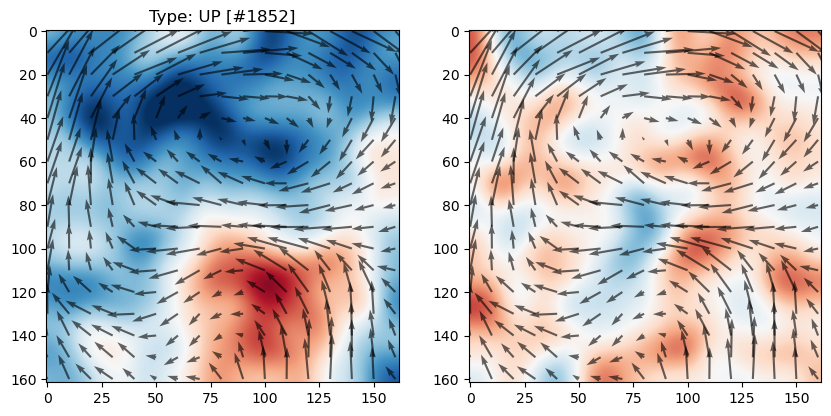

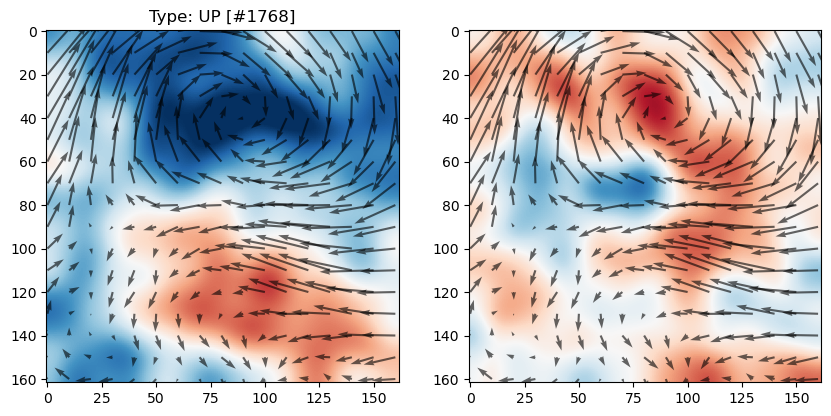

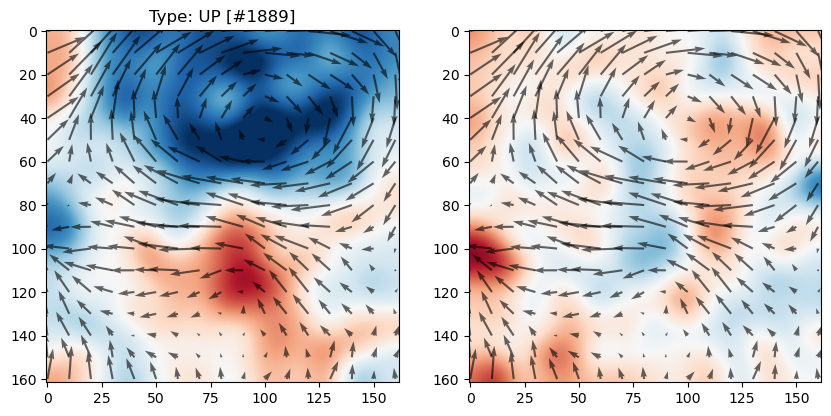

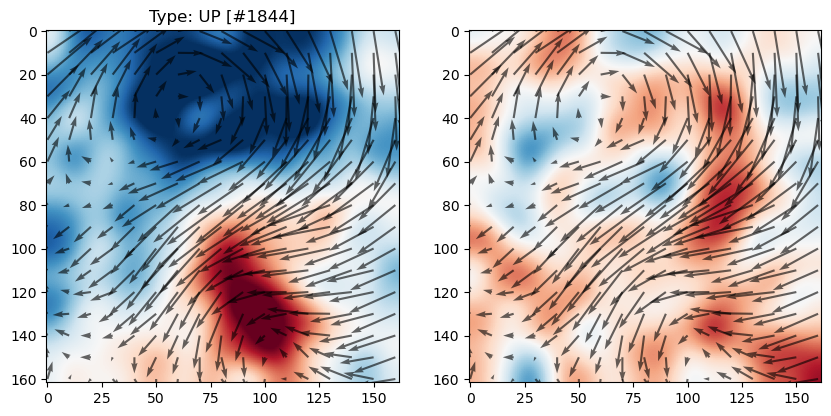

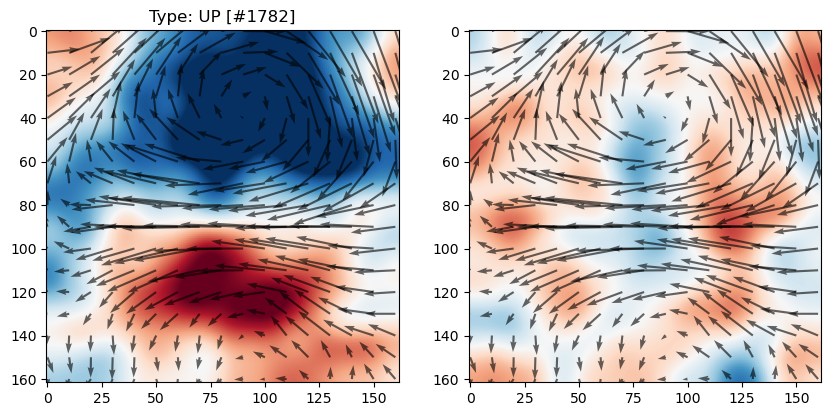

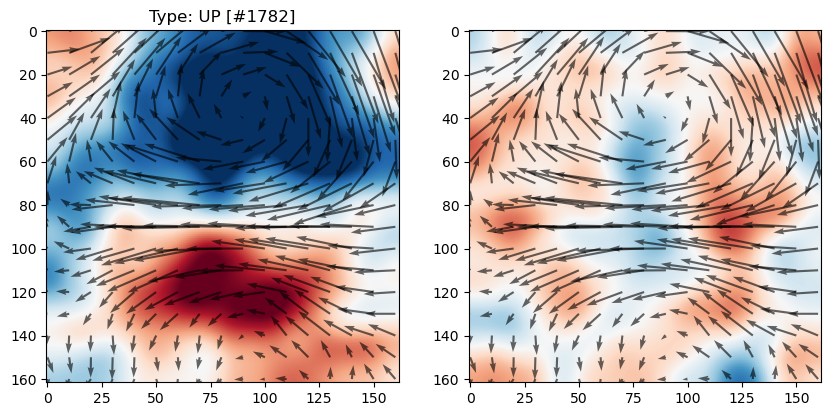

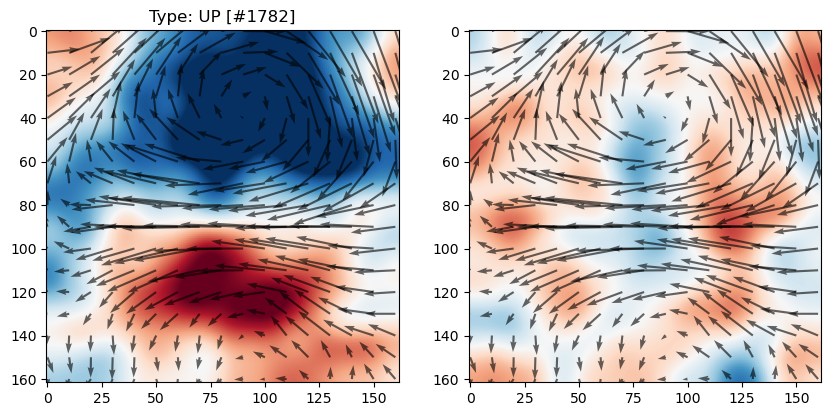

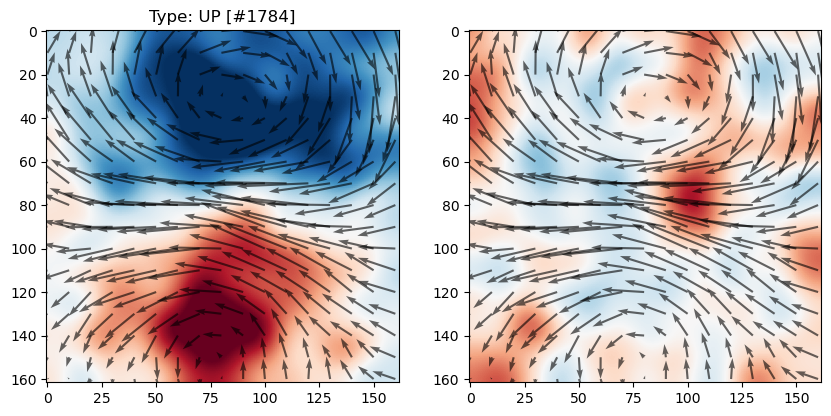

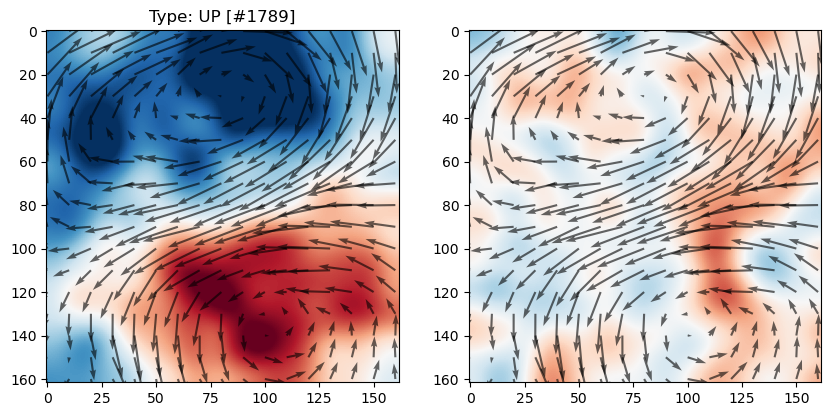

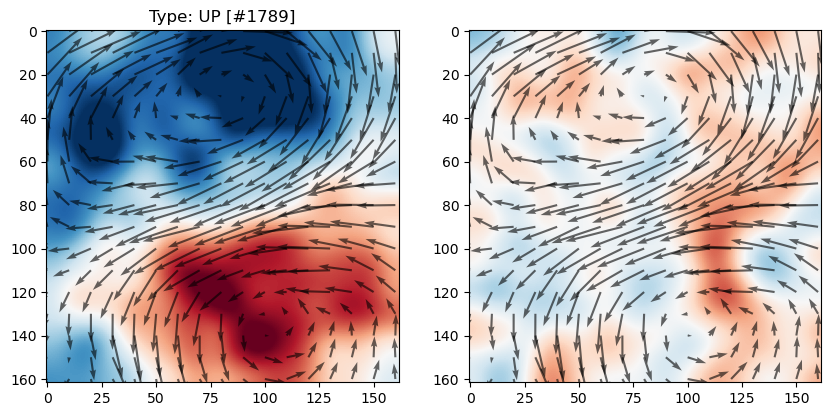

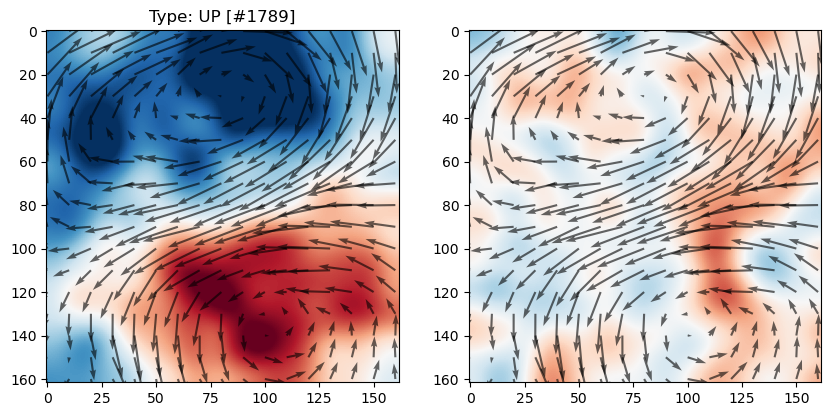

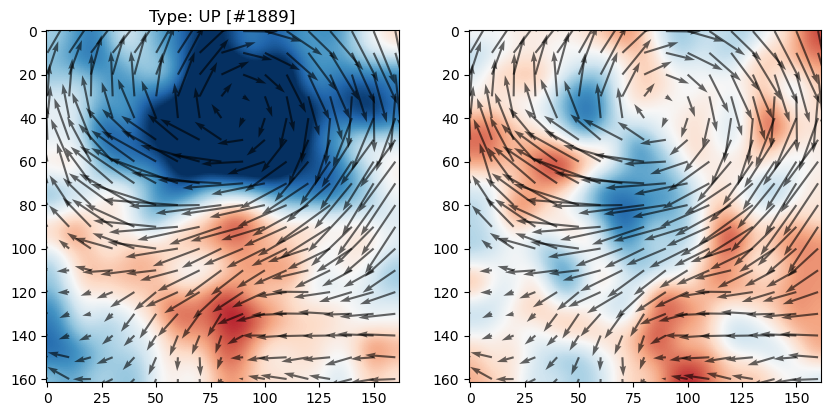

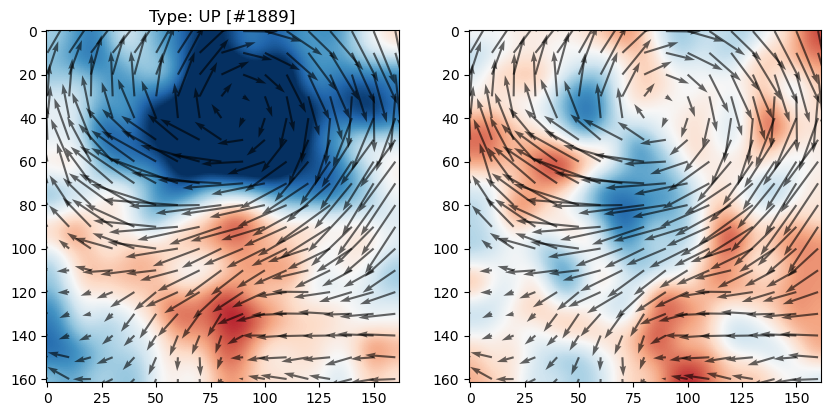

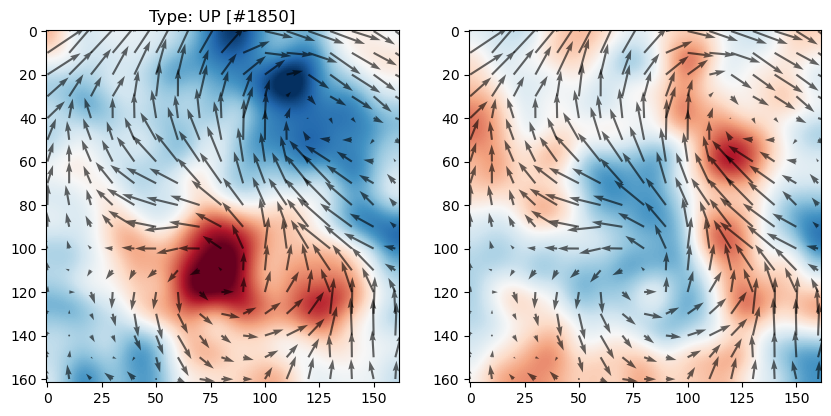

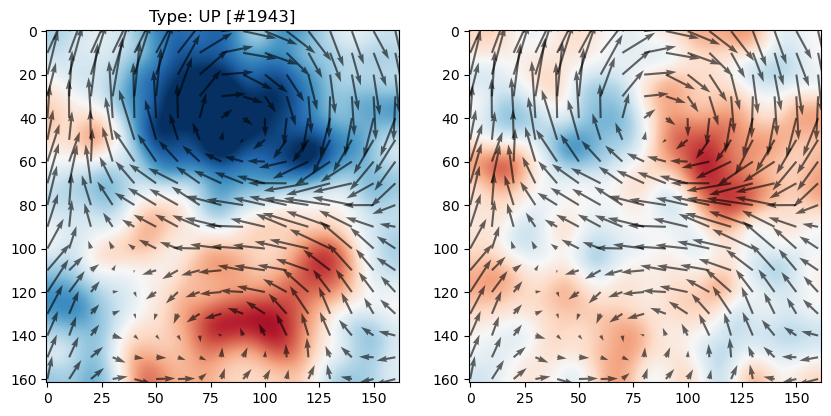

In [4]:
box = 230
ori_sigma = 21
flow_sigma = 15

for exp in exp_list[::-1]:
    tiff = Image.open(exp)
    tiff_frame_list = multiTiff_to_list(tiff)

    u_v_count = Parallel(n_jobs=-1)(delayed(defect_flow_frame_average)(
        img1, img2, 
        analyze_defects(img1, sigma=ori_sigma)[1][['x','y','ang1']].rename(columns={"x":"xp", "y":"yp", "ang1":"angp1"}),
        defect_type="all", 
        box=(int(box),int(box)),
        sigma=flow_sigma,
        filt=1,
        # edge=0,
        edge=200,
        ) for img1,img2 in zip(tiff_frame_list[:-1], tiff_frame_list[1:]))

    u, v, count = [], [], []
    for q in u_v_count:
        if q:
            u.append(q[0])
            v.append(q[1])
            count.append(q[2])
    u = np.array(u)
    v = np.array(v)
    count = np.array(count)  

    n, m = 0,-1 #800,900 #600,800 #450,550 #150,250 #50,150
    u_up = np.average(u[count!= 0][n:m,:,:], axis=0, weights=count[count!= 0][n:m])
    v_up = np.average(v[count!= 0][n:m,:,:], axis=0, weights=count[count!= 0][n:m])

    filt = 7
    step = 10
    vscale = 5
    vort_mag, div_mag = .03, .03

    fig, axs = plt.subplots(1,2, figsize=(10,5))
    # for ax in axs.ravel(): ax.axis('off')
    ax1, ax2 = axs.ravel()

    field = np.stack((u_up, v_up), axis=-1)
    y, x = np.mgrid[0:u_up.shape[0], 0:u_up.shape[1]] 
    vorticity = gaussian_filter(curl_npgrad(field), sigma=filt)
    c1 = ax1.imshow(vorticity, cmap='RdBu', vmin=-vort_mag, vmax=vort_mag)
    ax1.quiver(x[::step, ::step], y[::step, ::step], 
            u_up[::step, ::step], -v_up[::step, ::step],  color='k',
            width=.006, scale=vscale, alpha=.6)
    ax1.set_title("Type: %1s [#%1d]" % ("UP", np.sum(count)))

    divergence = gaussian_filter(divergence_npgrad(field), sigma=filt)
    c2 = ax2.imshow(divergence, cmap='RdBu', vmin=-div_mag, vmax=div_mag)
    ax2.quiver(x[::step, ::step], y[::step, ::step], 
            u_up[::step, ::step], -v_up[::step, ::step],  color='k',
            width=.006, scale=vscale, alpha=.6)
    
    fig.savefig(r"C:\Users\victo\OneDrive - BGU\DATA\Odd_test\Images\av_flow"
                 + "/" + str(tiff.size[0]) + "_" + Path(exp).name.split(".")[0]
                   +"_box230.png")

In [ ]:
'''PLOT DIRECTOR AND FLOW FIELDs'''
s = 30
fig, ax = plt.subplots()
ax.clear(); ax.axis('off') 

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img1)
ax.imshow(img_clahe, cmap="gray")  

# Director field
ax.quiver(x[::s,::s], y[::s,::s],
    np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], 
    headaxislength=0, headwidth=0, headlength=0, width=.004, 
    color="lawngreen", scale=25, pivot='mid', alpha=.6)
    
# Defects
alpha_half, scale_half = .8, 30    
ax.plot(plushalf['x'], plushalf['y'],'ro',markersize=8, alpha=alpha_half)
ax.quiver(plushalf['x'], plushalf['y'], 
    np.cos(plushalf['ang1']), -np.sin(plushalf['ang1']), 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

ax.plot(minushalf['x'], minushalf['y'],'bo',markersize=6, alpha=alpha_half)
for j in range(3):
    ax.quiver(minushalf['x'], minushalf['y'], 
        np.cos(minushalf['ang'+str(j+1)]), -np.sin(minushalf['ang'+str(j+1)]), 
        headaxislength=0, headwidth=0, headlength=0, color='b', scale=scale_half, alpha=alpha_half)
    
# Flow field

ax.quiver(x[::s, ::s], y[::s, ::s], 
    flow[::s, ::s, 0], -flow[::s, ::s, 1], 
    color="r", scale=150, alpha=.6, width=.007, minlength=0) 

In [27]:
frame_num,_ , im_width

(101, 1992, 1372)

In [ ]:
minimal_track = 3
exp_num = 4
folder = r"C:\Users\victo\Downloads\SB_lab\HBEC\s" + str(exp_num) + "(120-919)"


plushalf_df = pd.read_csv(folder + r"\Defects\PlusHalf1.csv")
first_frame = np.max([minushalf_df["frame"].min(), plushalf_df["frame"].min()]) # Validate this number in image folders
last_frame = np.min([minushalf_df["frame"].max(), plushalf_df["frame"].max()])   # Validate this number in image folders

image_list_all = glob.glob(folder + r"\Raw\*.tif")
image_list_all = natsorted(image_list_all, key=lambda y: y.lower())
image_list = image_list_all[first_frame-1:last_frame:1]

plus_minus_df = pd.read_csv(folder + r"\Defects\PlusAndMinusTM.csv").dropna(subset='TRACK_ID')
plus_minus_df = plus_minus_df.groupby('TRACK_ID').filter(lambda x : len(x)>minimal_track).copy()

plus_minus_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_HBEC_s" + str(exp_num) + ".csv").dropna(subset=["min_id","creation"])
plus_minus_df = plus_minus_df.groupby('plus_id').filter(lambda x : len(x)>minimal_track).copy()
df_plus = pd.DataFrame()
df_plus[['xp', 'yp', 'angp1','FRAME']] = plus_minus_df[['xp','yp','angp1','FRAME']][plus_minus_df.fuse_up & plus_minus_df.creation].copy()


In [ ]:
box = 400
n_jobs = os.cpu_count()-6

img_width = cv2.imread(image_list[0]).shape[1]
first_frame = 1
last_frame = 200#first_frame + len(image_list[first_frame:]) - 1
print(image_list[last_frame])
print("Total length: %s" % len(image_list[first_frame+1:last_frame]))

u_v_countA = Parallel(n_jobs=n_jobs)(delayed(defect_flow_frame_average)(
    # --- LEFT ----
    cv2.imread(img1)[:,:,0],cv2.imread(img2)[:,:,0], 
    df_plus[df_plus.FRAME==frame],
    defect_type="all", 
    box=(int(box),int(box)),
    filt=1
    ) for (frame,img1),img2 in zip(enumerate(image_list[first_frame:last_frame-1]),image_list[first_frame+1:last_frame]))
